# Modeling with ACLED features — Ukraine conflict escalation

Rebuilds the feature panel with **ACLED weekly sub-event-type features** merged
into the GDELT panel, then reruns the same walk-forward CV / hold-out /
forecast pipeline as `src/pipeline.py`.

ACLED columns (joined on `week_start`):
- totals: `acled_total_events`, `acled_total_fatalities`, `acled_total_population_exposure`
- lag/WoW: `acled_total_events_lag1`, `acled_total_fatalities_lag1`, `acled_events_change_wow`
- per `sub_event_type`: `acled_{type}_events`, `acled_{type}_fatalities`

Outputs land in `outputs/with_acled/` so the original GDELT-only
`outputs/` artifacts are left untouched for comparison.

**Contents**
1. Setup & rebuild feature panel
2. Hold-out / CV split
3. Ablation: GDELT-only vs GDELT+ACLED (hold-out)
4. Walk-forward CV (with ACLED)
5. Hold-out evaluation (with ACLED)
6. Feature importance
7. Future forecast
8. Takeaways


In [1]:
import sys
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_config, repo_path, write_json
from src.data.build_acled_weekly import build_acled_weekly
from src.features.feature_engineering import (
    BASE_FEATURE_COLUMNS, build_features, get_feature_columns, acled_feature_columns,
)
from src.models import ml_model
from src.validation.walk_forward import generate_folds, split_holdout
from src.pipeline import (
    run_cv, summarize_cv, run_holdout, compute_mase_vs_baseline_table,
    build_future_forecast, make_figures,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

cfg = load_config()
SEED = cfg["random_seed"]
HORIZONS = cfg["target"]["horizons"]
MAX_H = max(HORIZONS)
OUT_DIR = repo_path("outputs", "with_acled")
OUT_DIR.mkdir(parents=True, exist_ok=True)
cfg["target"], cfg["validation"], str(OUT_DIR)


({'variant': 'A',
  'horizons': [1, 2, 3, 4],
  'strategy': 'direct',
  'escalation_rolling_window_weeks': 52,
  'escalation_zscore_k': 2.0},
 {'holdout_weeks': 12,
  'cv_initial_train_weeks': 52,
  'cv_step_weeks': 4,
  'min_test_weeks_per_fold': 4},
 '/home/romanrussia/Code_git/GDETL/outputs/with_acled')

## 1. Rebuild feature panel (GDELT weekly + ACLED)

Uses the existing GDELT `weekly_panel.parquet` and rebuilds ACLED weekly
aggregates, then merges them in `build_features`.


In [2]:
build_acled_weekly(cfg)

weekly = pd.read_parquet(repo_path(cfg["data"]["weekly_panel_path"]))
feature_df = build_features(weekly, cfg, HORIZONS)
feature_df["week_start"] = pd.to_datetime(feature_df["week_start"]).dt.date

FEATURE_COLS = get_feature_columns(feature_df)
ACLED_COLS = acled_feature_columns(feature_df)

print(f"feature_df: {feature_df.shape[0]} weeks × {feature_df.shape[1]} cols")
print(f"model features: {len(FEATURE_COLS)}  "
      f"(base={len(BASE_FEATURE_COLUMNS)}, acled={len(ACLED_COLS)})")
print(f"ACLED coverage: {(feature_df['acled_total_events'] > 0).mean():.1%} weeks with events")
feature_df[["week_start", "conflict_count", "acled_total_events",
            "acled_total_fatalities", "acled_air_drone_strike_events",
            "acled_armed_clash_events"]].tail(8)


[build_acled_weekly] long=4547 rows (453 weeks × 25 sub_event_types) -> /home/romanrussia/Code_git/GDETL/data/processed/acled_weekly_long.parquet
[build_acled_weekly] wide=453 weeks × 81 cols (2017-12-30 .. 2026-08-29) -> /home/romanrussia/Code_git/GDETL/data/processed/acled_weekly_panel.parquet
      week week_label  total_events  total_fatalities  total_population_exposure
2026-07-25   2026-W31          2091               999                    9949720
2026-08-01   2026-W32          2039               862                    8693991
2026-08-08   2026-W33          1984               920                    9045922
2026-08-15   2026-W34          1974               897                    6949827
2026-08-22   2026-W35          1863               903                    7159893
2026-08-29   2026-W36          1900              1112                          0
[feature_engineering] Merged ACLED features (56 model columns)
[feature_engineering] Built feature panel: 245 rows x 118 cols (78 model 

,week_start,conflict_count,acled_total_events,acled_total_fatalities,acled_air_drone_strike_events,acled_armed_clash_events
237,2026-07-13,1944,2053,982,1148,578
238,2026-07-20,2176,2049,906,1114,508
239,2026-07-27,2233,2091,999,1177,533
240,2026-08-03,2192,2039,862,1201,533
241,2026-08-10,2055,1984,920,1145,480
242,2026-08-17,1930,1974,897,1140,514
243,2026-08-24,1569,1863,903,1156,454
244,2026-08-31,1742,1900,1112,1182,488


## 2. Hold-out / CV split

Same protocol as the main pipeline: last 12 realized weeks held out;
expanding-window walk-forward on the remainder.


CV pool: 230 weeks | Hold-out: 12 weeks from 2026-06-15
Walk-forward folds: 44


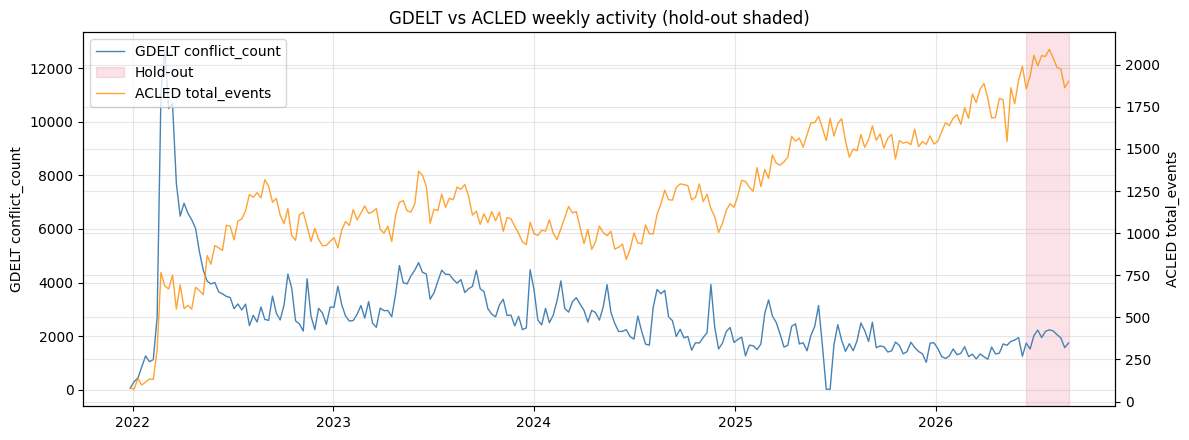

In [3]:
cv_pool, full_df, holdout_start, holdout_target_weeks = split_holdout(
    feature_df, cfg["validation"]["holdout_weeks"], MAX_H
)
folds = generate_folds(
    len(cv_pool),
    cfg["validation"]["cv_initial_train_weeks"],
    cfg["validation"]["cv_step_weeks"],
    cfg["validation"]["min_test_weeks_per_fold"],
)
print(f"CV pool: {len(cv_pool)} weeks | Hold-out: {len(holdout_target_weeks)} weeks from {holdout_start}")
print(f"Walk-forward folds: {len(folds)}")

fig, ax = plt.subplots()
ax.plot(feature_df["week_start"], feature_df["conflict_count"], color="steelblue", lw=1, label="GDELT conflict_count")
ax2 = ax.twinx()
ax2.plot(feature_df["week_start"], feature_df["acled_total_events"], color="darkorange", lw=1, alpha=0.8, label="ACLED total_events")
ax.axvspan(holdout_start, feature_df["week_start"].max(), color="crimson", alpha=0.12, label="Hold-out")
ax.set_ylabel("GDELT conflict_count")
ax2.set_ylabel("ACLED total_events")
ax.set_title("GDELT vs ACLED weekly activity (hold-out shaded)")
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper left")
fig.tight_layout()
plt.show()


## 3. Ablation — GDELT-only vs GDELT+ACLED (hold-out)

Same CV pool / hold-out weeks; only the XGBoost feature set changes.
Baselines (naive / rolling mean / ETS) are feature-free and identical.


features  gdelt+acled  gdelt_only
horizon                          
1               0.561       0.623
2               0.705       0.646
3               0.838       0.895
4               0.741       0.752

   features  horizon  MASE  sMAPE    RMSE     MAE
 gdelt_only        1 0.623 16.246 335.147 299.522
 gdelt_only        2 0.646 16.640 374.191 310.461
 gdelt_only        3 0.895 24.147 498.688 429.962
 gdelt_only        4 0.752 19.739 447.852 361.486
gdelt+acled        1 0.561 14.553 317.393 269.498
gdelt+acled        2 0.705 18.319 406.135 338.984
gdelt+acled        3 0.838 22.281 463.557 402.833
gdelt+acled        4 0.741 19.389 437.051 356.330


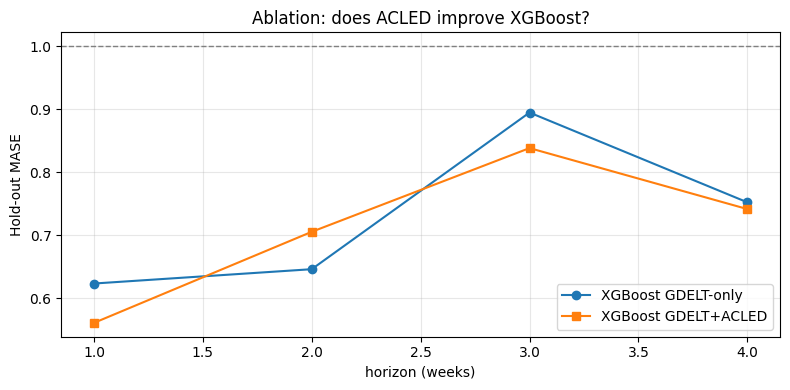

,features,horizon,MASE,sMAPE,RMSE,MAE
0,gdelt_only,1,0.623221,16.245868,335.146805,299.521861
1,gdelt_only,2,0.645983,16.640020,374.191295,310.461212
2,gdelt_only,3,0.894632,24.147081,498.687695,429.962494
3,gdelt_only,4,0.752151,19.738576,447.851669,361.485535
4,gdelt+acled,1,0.560750,14.552653,317.392795,269.497721
5,gdelt+acled,2,0.705331,18.319474,406.134645,338.983714
6,gdelt+acled,3,0.838182,22.281173,463.557157,402.832570
7,gdelt+acled,4,0.741424,19.389460,437.050933,356.330363


In [4]:
holdout_base = run_holdout(cv_pool, full_df, holdout_target_weeks, HORIZONS, SEED,
                           feature_cols=list(BASE_FEATURE_COLUMNS))
holdout_acled = run_holdout(cv_pool, full_df, holdout_target_weeks, HORIZONS, SEED,
                            feature_cols=FEATURE_COLS)

rows = []
for tag, summary in [("gdelt_only", holdout_base), ("gdelt+acled", holdout_acled)]:
    for h, models in summary["regression"].items():
        for m, rep in models.items():
            if m != "xgboost":
                continue
            rows.append({"features": tag, "horizon": h, "MASE": rep["MASE"],
                         "sMAPE": rep["sMAPE"], "RMSE": rep["RMSE"], "MAE": rep["MAE"]})
ablation = pd.DataFrame(rows)
print(ablation.pivot(index="horizon", columns="features", values="MASE").round(3).to_string())
print()
print(ablation.round(3).to_string(index=False))

piv = ablation.pivot(index="horizon", columns="features", values="MASE")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(piv.index, piv["gdelt_only"], "o-", label="XGBoost GDELT-only")
ax.plot(piv.index, piv["gdelt+acled"], "s-", label="XGBoost GDELT+ACLED")
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("horizon (weeks)")
ax.set_ylabel("Hold-out MASE")
ax.set_title("Ablation: does ACLED improve XGBoost?")
ax.legend()
fig.tight_layout()
plt.show()
ablation


## 4. Walk-forward CV (GDELT + ACLED)

Full model suite with the expanded feature set.


In [5]:
cv_results, cv_results_event = run_cv(
    cv_pool, folds, HORIZONS, SEED, feature_cols=FEATURE_COLS
)
cv_summary = summarize_cv(cv_results, cv_results_event, cv_pool["conflict_count"].to_numpy())

cv_rows = []
for h, models in cv_summary["regression"].items():
    for m, rep in models.items():
        cv_rows.append({"horizon": h, "model": m, "MASE": rep["MASE"],
                        "sMAPE": rep["sMAPE"], "RMSE": rep["RMSE"], "n": rep["n"]})
cv_table = pd.DataFrame(cv_rows).sort_values(["horizon", "MASE"])
print("=== CV regression (pooled OOF) ===")
print(cv_table.round(3).to_string(index=False))
cv_table


[pipeline] CV fold 0: train=52 rows, test=4 rows (2022-12-26 .. 2023-01-16)


[pipeline] CV fold 1: train=56 rows, test=4 rows (2023-01-23 .. 2023-02-13)


[pipeline] CV fold 2: train=60 rows, test=4 rows (2023-02-20 .. 2023-03-13)


[pipeline] CV fold 3: train=64 rows, test=4 rows (2023-03-20 .. 2023-04-10)


[pipeline] CV fold 4: train=68 rows, test=4 rows (2023-04-17 .. 2023-05-08)


...

[pipeline] CV fold 40: train=212 rows, test=4 rows (2026-01-19 .. 2026-02-09)


[pipeline] CV fold 41: train=216 rows, test=4 rows (2026-02-16 .. 2026-03-09)


[pipeline] CV fold 42: train=220 rows, test=4 rows (2026-03-16 .. 2026-04-06)


[pipeline] CV fold 43: train=224 rows, test=4 rows (2026-04-13 .. 2026-05-04)
=== CV regression (pooled OOF) ===
 horizon                model  MASE  sMAPE     RMSE   n
       1       baseline_naive 0.804 15.855  518.735 171
       1 baseline_rollingmean 0.892 17.602  577.788 171
       1              xgboost 0.912 17.637  557.069 171
       1                  ets 1.750 36.491 1157.054 171
       2 baseline_rollingmean 1.002 19.729  641.241 171
       2              xgboost 1.062 20.633  654.100 171
       2       baseline_naive 1.087 21.774  708.202 171
       2                  ets 1.793 37.978 1155.934 171
       3 baseline_rollingmean 1.025 20.069  652.763 171
       3              xgboost 1.051 19.843  707.949 171
       3       baseline_naive 1.169 23.783  767.618 171
       3                  ets 1.741 36.872 1121.128 171
       4 baseline_rollingmean 1.026 20.095  656.306 171
       4       baseline_naive 1.181 24.173  760.113 171
       4              xgboost 1.347 24.424  927

,horizon,model,MASE,sMAPE,RMSE,n
0,1,baseline_naive,0.804217,15.854834,518.735332,171
1,1,baseline_rollingmean,0.891854,17.601525,577.787517,171
3,1,xgboost,0.912385,17.637113,557.068966,171
2,1,ets,1.749745,36.490595,1157.053630,171
5,2,baseline_rollingmean,1.001782,19.729163,641.241149,171
7,2,xgboost,1.062475,20.633217,654.099528,171
4,2,baseline_naive,1.086684,21.774180,708.202432,171
6,2,ets,1.793446,37.978486,1155.933610,171
9,3,baseline_rollingmean,1.024533,20.068895,652.763396,171
11,3,xgboost,1.051311,19.842906,707.948550,171


## 5. Hold-out evaluation (GDELT + ACLED)


=== Hold-out results ===
 horizon                model  MASE  sMAPE   RMSE  vs_baseline_pct
       1       baseline_naive 0.490  13.13 276.29              NaN
       1 baseline_rollingmean 0.479  12.13 292.11              2.4
       1                  ets 1.194  35.69 655.02           -143.6
       1              xgboost 0.561  14.55 317.39            -14.4
       2       baseline_naive 0.520  13.48 310.41              NaN
       2 baseline_rollingmean 0.603  15.21 335.48            -15.9
       2                  ets 1.194  35.69 655.02           -129.5
       2              xgboost 0.705  18.32 406.13            -35.5
       3       baseline_naive 0.693  18.09 396.36              NaN
       3 baseline_rollingmean 0.674  17.03 366.98              2.7
       3                  ets 1.194  35.69 655.02            -72.3
       3              xgboost 0.838  22.28 463.56            -20.9
       4       baseline_naive 0.698  18.09 438.99              NaN
       4 baseline_rollingmean 0.703  

[pipeline] Saved figures to /home/romanrussia/Code_git/GDETL/outputs/with_acled/figures


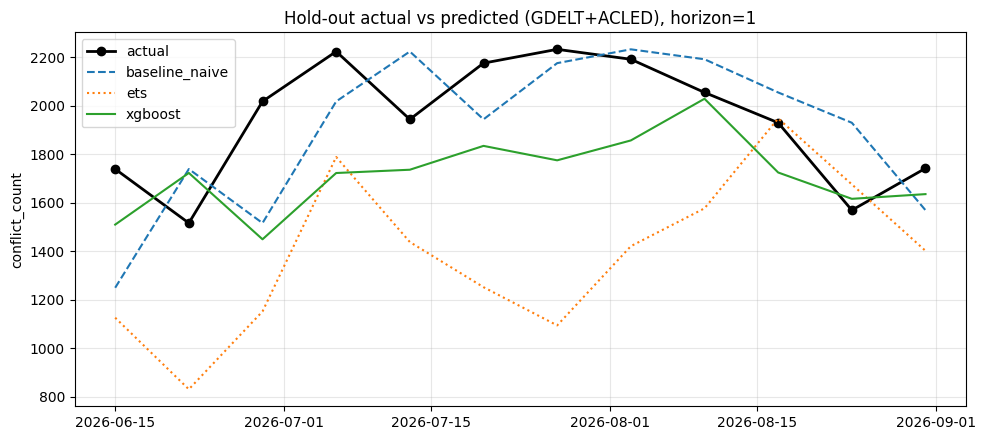

,horizon,model,MASE,sMAPE,RMSE,vs_baseline_pct
0,1,baseline_naive,0.490,13.13,276.29,NaN
1,1,baseline_rollingmean,0.479,12.13,292.11,2.4
2,1,ets,1.194,35.69,655.02,-143.6
3,1,xgboost,0.561,14.55,317.39,-14.4
4,2,baseline_naive,0.520,13.48,310.41,NaN
5,2,baseline_rollingmean,0.603,15.21,335.48,-15.9
6,2,ets,1.194,35.69,655.02,-129.5
7,2,xgboost,0.705,18.32,406.13,-35.5
8,3,baseline_naive,0.693,18.09,396.36,NaN
9,3,baseline_rollingmean,0.674,17.03,366.98,2.7


In [6]:
holdout_summary = holdout_acled  # reuse ablation run
results_table = compute_mase_vs_baseline_table(holdout_summary)
print("=== Hold-out results ===")
print(results_table.to_string(index=False))

make_figures(feature_df, holdout_summary, OUT_DIR)

h = 1
reg = holdout_summary["regression"][h]
fig, ax = plt.subplots(figsize=(10, 4.5))
weeks = pd.to_datetime(reg["xgboost"]["week_start"])
ax.plot(weeks, reg["xgboost"]["y_true"], "o-", color="black", label="actual", lw=2)
for m, style in [("baseline_naive", "--"), ("ets", ":"), ("xgboost", "-")]:
    ax.plot(weeks, reg[m]["y_pred"], style, label=m)
ax.set_title(f"Hold-out actual vs predicted (GDELT+ACLED), horizon={h}")
ax.set_ylabel("conflict_count")
ax.legend()
fig.tight_layout()
plt.show()
results_table


## 6. Feature importance (XGBoost, horizon=1)

Gain-based importance on the CV pool — highlights whether ACLED subtypes
are used by the model.


ACLED share of total gain: 23.5%

Top 20 features:
google_trends_score                               0.2187
cumulative_conflict_12w                           0.0823
rolling_mean_12w                                  0.0743
total_events_country                              0.0650
rolling_mean_4w                                   0.0581
conflict_count_t0                                 0.0547
conflict_count_lag12                              0.0457
acled_shelling_artillery_missile_attack_events    0.0380
weeks_since_major_spike                           0.0321
rolling_max_8w                                    0.0260
conflict_count_lag4                               0.0259
rolling_std_12w                                   0.0254
acled_total_events                                0.0234
acled_armed_clash_events                          0.0174
acled_peaceful_protest_events                     0.0126
acled_total_events_lag1                           0.0113
acled_total_fatalities_lag1          

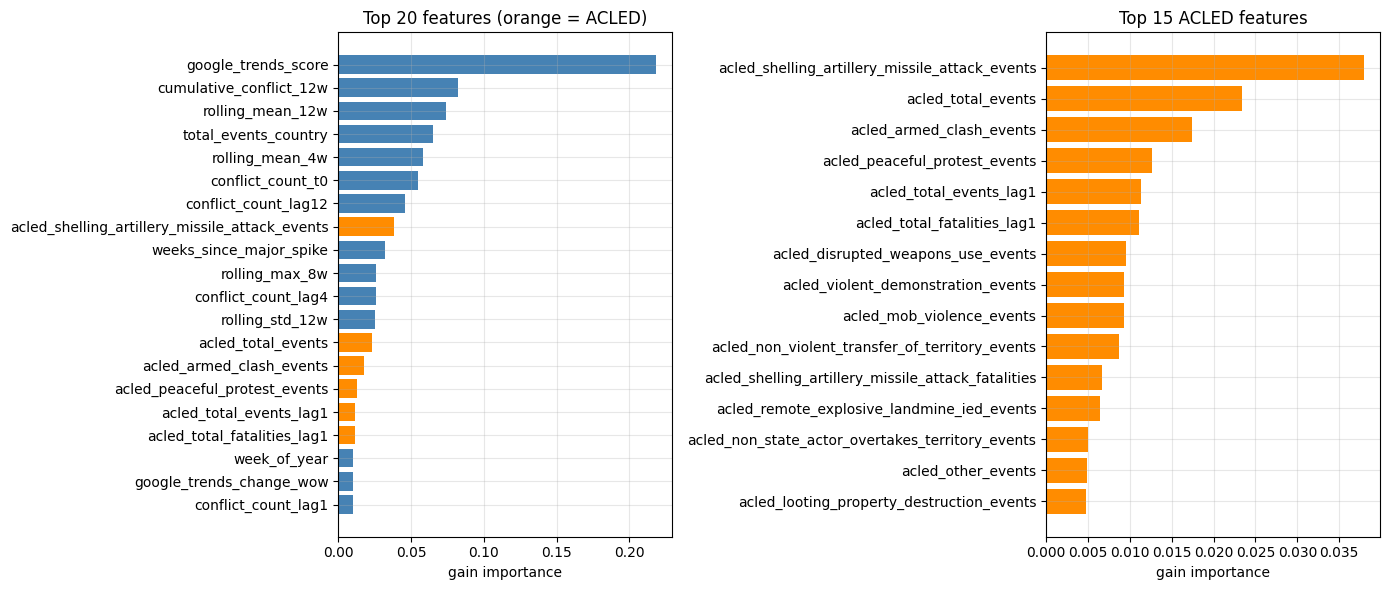

google_trends_score                               0.218679
cumulative_conflict_12w                           0.082309
rolling_mean_12w                                  0.074320
total_events_country                              0.065006
rolling_mean_4w                                   0.058062
conflict_count_t0                                 0.054736
conflict_count_lag12                              0.045704
acled_shelling_artillery_missile_attack_events    0.037963
weeks_since_major_spike                           0.032072
rolling_max_8w                                    0.026016
conflict_count_lag4                               0.025870
rolling_std_12w                                   0.025444
acled_total_events                                0.023379
acled_armed_clash_events                          0.017407
acled_peaceful_protest_events                     0.012630
acled_total_events_lag1                           0.011297
acled_total_fatalities_lag1                       0.0111

In [7]:
model = ml_model.fit_full_regressor(cv_pool, FEATURE_COLS, "target_count_h1", SEED)
imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
imp_acled = imp[imp.index.str.startswith("acled_")]
print(f"ACLED share of total gain: {imp_acled.sum() / imp.sum():.1%}")
print("\nTop 20 features:")
print(imp.head(20).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top = imp.head(20).iloc[::-1]
colors = ["darkorange" if i.startswith("acled_") else "steelblue" for i in top.index]
axes[0].barh(top.index, top.values, color=colors)
axes[0].set_title("Top 20 features (orange = ACLED)")
axes[0].set_xlabel("gain importance")

top_a = imp_acled.head(15).iloc[::-1]
axes[1].barh(top_a.index, top_a.values, color="darkorange")
axes[1].set_title("Top 15 ACLED features")
axes[1].set_xlabel("gain importance")
fig.tight_layout()
plt.show()
imp.head(25)


## 7. Future forecast (next 1–4 weeks)


In [8]:
future_forecast = build_future_forecast(
    feature_df, cfg, SEED, feature_cols=FEATURE_COLS
)
future_forecast.to_csv(OUT_DIR / "forecast.csv", index=False)
print(future_forecast.to_string(index=False))

metrics_out = {
    "config": cfg,
    "n_weeks_total": int(len(feature_df)),
    "n_features": len(FEATURE_COLS),
    "n_acled_features": len(ACLED_COLS),
    "feature_columns": FEATURE_COLS,
    "cv_n_folds": len(folds),
    "cv_summary": cv_summary,
    "ablation_holdout_mase": ablation.to_dict(orient="records"),
    "holdout_summary": {
        "regression": {h: {m: {k: v for k, v in rep.items() if k not in ("y_true", "y_pred", "week_start")}
                            for m, rep in models.items()}
                       for h, models in holdout_summary["regression"].items()},
        "classification": holdout_summary["classification"],
    },
    "results_table_holdout": results_table.to_dict(orient="records"),
}
write_json(OUT_DIR / "metrics.json", metrics_out)
print(f"\nWrote {OUT_DIR / 'forecast.csv'}")
print(f"Wrote {OUT_DIR / 'metrics.json'}")
future_forecast


country forecast_week  horizon target_type predicted_value predicted_prob  ci_lower  ci_upper   model
Ukraine      2026-W37        1       count          1841.4                  1509.60   3738.50 xgboost
Ukraine      2026-W37        1       event                           0.01      0.01      0.02 xgboost
Ukraine      2026-W38        2       count          1904.5                  1406.40   3762.20 xgboost
Ukraine      2026-W38        2       event                           0.01      0.01      0.02 xgboost
Ukraine      2026-W39        3       count          1883.4                  1472.90   4309.80 xgboost
Ukraine      2026-W39        3       event                           0.01      0.01      0.02 xgboost
Ukraine      2026-W40        4       count          1985.7                  1554.70   3941.00 xgboost
Ukraine      2026-W40        4       event                           0.01      0.01      0.02 xgboost

Wrote /home/romanrussia/Code_git/GDETL/outputs/with_acled/forecast.csv
Wrote /hom

,country,forecast_week,horizon,target_type,predicted_value,predicted_prob,ci_lower,ci_upper,model
0,Ukraine,2026-W37,1,count,1841.4,,1509.60,3738.50,xgboost
1,Ukraine,2026-W37,1,event,,0.01,0.01,0.02,xgboost
2,Ukraine,2026-W38,2,count,1904.5,,1406.40,3762.20,xgboost
3,Ukraine,2026-W38,2,event,,0.01,0.01,0.02,xgboost
4,Ukraine,2026-W39,3,count,1883.4,,1472.90,4309.80,xgboost
5,Ukraine,2026-W39,3,event,,0.01,0.01,0.02,xgboost
6,Ukraine,2026-W40,4,count,1985.7,,1554.70,3941.00,xgboost
7,Ukraine,2026-W40,4,event,,0.01,0.01,0.02,xgboost


## 8. Takeaways

- Main feature panel now includes ACLED weekly aggregates pivoted by
  `sub_event_type` (events + fatalities) plus totals / lags.
- This notebook evaluates the **same models and split** with the expanded
  feature set and writes results under `outputs/with_acled/`.
- Compare the ablation table (section 3): if GDELT+ACLED MASE is lower than
  GDELT-only, ACLED adds predictive signal for GDELT conflict counts;
  otherwise the value is mainly as an external sanity check / media-bias
  contrast (GDELT news volume vs curated ACLED ground truth can diverge).
- Feature-importance plot shows which ACLED subtypes the model actually uses.
